# Once things are generated - what is selecting them like?

## Imports

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gaianir_open_clusters.config import RESULTS_DIRECTORY
from gaianir_open_clusters.gaia_nir_config import SIMULATION_CLUSTER_PARAMETERS

from hr_selection_function import HR24SelectionFunction, NStarsPredictor

from sklearn.mixture import GaussianMixture


In [8]:
simulated_clusters = pd.read_parquet(RESULTS_DIRECTORY / "simulated_clusters.parquet")

## Helper functions

In [52]:
def errors_to_median_cubed_error(pmra_error, pmdec_error, parallax_error):
    """Function that converts astrometric errors to the cubed error needed for cluster
    density calculations.

    Adds a scale factor that accounts for an oversight in the Hunt+26 cluster selection
    function. In it, they assumed sigma_parallax = sigma_pmra = sigma_pmdec. This is
    true for Gaia DR3... only, due to the timespan of its observations. A correction
    factor is required to convert proper motions with a time baseline of anything other
    than 34 months to be scaled as if they're a parallax error.

    See https://www.cosmos.esa.int/web/gaia/science-performance
    """
    return (
        np.nanmedian(pmra_error)
        / 1.03
        * np.nanmedian(pmdec_error)
        / 0.89
        * np.nanmedian(parallax_error)
    )


def measure_cluster_density(
    members,
    magnitude_limits,
    use_combined=True,
    estimate_gaia_dr3_from_dr4=True,
    missions=("gaianir-l", "gaianir-m", "gaia_dr5", "gaia_dr4", "gaia_dr3"),
):
    result = dict()

    for mission in missions:
        maglim = magnitude_limits[mission]
        mission_name = mission

        pm_scale, parallax_scale = 1.0, 1.0
        if estimate_gaia_dr3_from_dr4 and mission == "gaia_dr3":
            key = "gaia_dr4"
            parallax_scale = np.sqrt(66 / 34)
            pm_scale = 66 / 34 * parallax_scale
            mission = "gaia_dr4"

        key = mission
        if use_combined and "gaianir" in mission:
            key = key + "_combined"

        subsample = members.loc[
            (members[mission]) & (members[maglim["band"]] < maglim["limit"])
        ]

        result[f"n_stars_{mission_name}"] = len(subsample)
        if len(subsample) > 0:
            result[f"med_error_{mission_name}"] = errors_to_median_cubed_error(
                subsample[f"pmra_error_{key}"] * pm_scale,
                subsample[f"pmdec_error_{key}"] * pm_scale,
                subsample[f"parallax_error_{key}"] * parallax_scale,
            )
        else:
            result[f"med_error_{mission_name}"] = np.inf
        result[f"rho_cluster_{mission_name}"] = (
            result[f"n_stars_{mission_name}"] / result[f"med_error_{mission_name}"]
        )

    return result


def measure_region_density():
    pass

In [139]:
region = pd.read_parquet(RESULTS_DIRECTORY / "regions/120.000_0.000.parquet")

In [140]:
mission = "gaianir-l"

true_parallax = 1 / 20
subsample = region.loc[
    (region[f"parallax_{mission}"] > true_parallax - 0.05)
    & (region[f"parallax_{mission}"] < true_parallax + 0.05)
    & (region[f"uncrowded_{mission.replace("_dr4", "").replace("_dr5", "")}"])
]

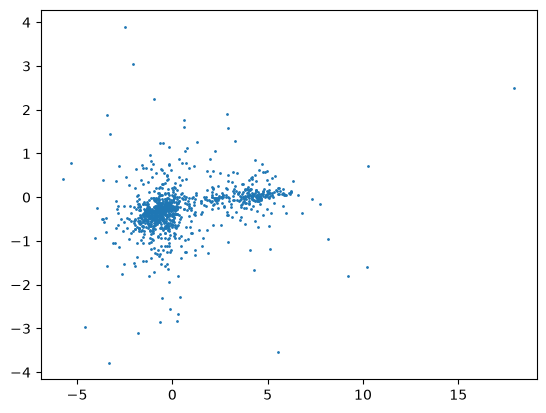

In [141]:
plt.scatter(subsample[f'pmra_{mission}'], subsample[f'pmdec_{mission}'], s=1)

In [ ]:
mixture = GaussianMixture(n_components=3)
mixture.fi

## Measure densities

In [68]:
simulated_clusters = pd.read_parquet(RESULTS_DIRECTORY / "simulated_clusters.parquet")

In [65]:
magnitude_limits = {
    "gaianir-l": {"band": "gaianir_n", "limit": 20},
    "gaianir-m": {"band": "gaianir_n", "limit": 20},
    "gaia_dr5": {"band": "g_effective_gaia", "limit": 20},
    "gaia_dr4": {"band": "g_effective_gaia", "limit": 19.5},
    "gaia_dr3": {"band": "g_effective_gaia", "limit": 19},
}

In [66]:
cluster_density_df = {}
for i_row, a_row in simulated_clusters.iterrows():
    print(f"\r{i_row+1} of {len(simulated_clusters)}", end="")
    members = pd.read_parquet(RESULTS_DIRECTORY / a_row["path"])
    cluster_density_df[i_row] = measure_cluster_density(members, magnitude_limits)

cluster_density_df = pd.DataFrame.from_dict(cluster_density_df, orient="index")

1800 of 1800

In [69]:
simulated_clusters = simulated_clusters.join(cluster_density_df)

In [73]:
simulated_clusters['cluster'].unique()

<ArrowStringArray>
['berkeley_29', 'embedded', 'pleiades']
Length: 3, dtype: str

[Text(0.5, 1.0, 'n_stars')]

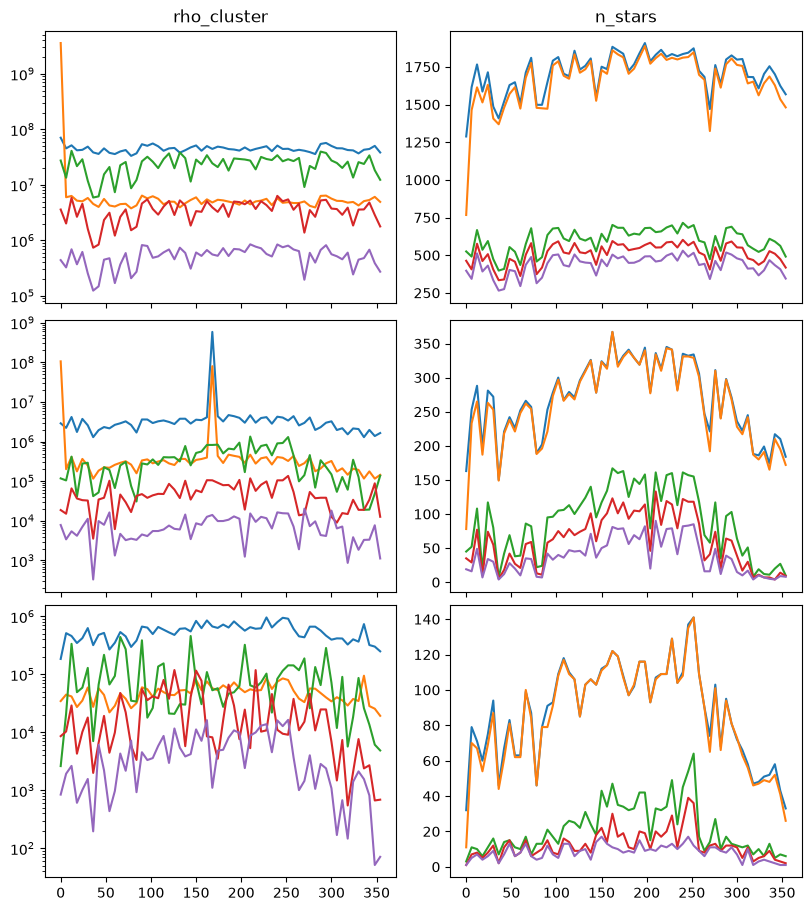

In [78]:
cluster = "berkeley_29"
distances = [2000, 10000, 20000]

fig, ax = plt.subplots(
    nrows=len(distances),
    ncols=2,
    figsize=(8, 3 * len(distances)),
    layout="constrained",
    sharex=True,
)

for an_ax, distance in zip(ax, distances):
    subsample = simulated_clusters.query(
        f"cluster=='{cluster}' and distance=={distance}"
    )
    for a_mission in magnitude_limits:
        an_ax[0].plot(
            subsample["l"], subsample[f"rho_cluster_{a_mission}"], label=a_mission
        )
        an_ax[1].plot(subsample["l"], subsample[f"n_stars_{a_mission}"])

    an_ax[0].set(yscale="log")
    # an_ax[1].set(yscale="log")

ax[0, 0].set(title="rho_cluster")
ax[0, 1].set(title="n_stars")